# Modélisation baseline

In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import numpy as np

In [12]:
# Chargement des splits
df_train = pd.read_csv(r"..\data_finale\featuring\train_featured.csv", encoding="utf-8-sig")
df_val   = pd.read_csv(r"..\data_finale\featuring\val_featured.csv", encoding="utf-8-sig")

In [13]:
# Sélection de la cible (Y) et des 2 variables naïves (X)
X_cols_naives = ["Performance_Gls", "Playing Time_MP"]
target_col = "market_value_in_eur"

In [14]:
# Correction des NA
# On filtre les dataframes pour ne garder que les lignes qui ont toutes leurs données
# sur les variables prédictives (X) ET la cible (y).
cols_a_verifier = X_cols_naives + [target_col]

df_train_clean = df_train.dropna(subset=cols_a_verifier)
df_val_clean = df_val.dropna(subset=cols_a_verifier)

print(f"Lignes après suppression des NA -> Train: {len(df_train_clean)} (vs {len(df_train)}) | Val: {len(df_val_clean)} (vs {len(df_val)})\n")

Lignes après suppression des NA -> Train: 7404 (vs 7404) | Val: 2431 (vs 2431)



In [15]:
# On extrait du jeu d'entraînement uniquement les colonnes de performance choisies
X_train = df_train_clean[X_cols_naives]
# On extrait la colonne que le modèle doit apprendre à prédire (la valeur marchande réelle)
y_train = df_train_clean[target_col]

# On effectue exactement la même séparation sur le jeu de validation
X_val = df_val_clean[X_cols_naives]
y_val = df_val_clean[target_col]

print(f"Variables utilisées pour le modèle naïf : {X_cols_naives}")
print(f"Variable cible : {target_col}\n")

Variables utilisées pour le modèle naïf : ['Performance_Gls', 'Playing Time_MP']
Variable cible : market_value_in_eur



In [16]:
# Entraînement du modèle naïf (Régression Linéaire)
modele_naif = LinearRegression()
modele_naif.fit(X_train, y_train)

# Prédictions sur le jeu d'entraînement et de validation
y_pred_train = modele_naif.predict(X_train)
y_pred_val = modele_naif.predict(X_val)

In [17]:
# Calcul des métriques de performance
def calculer_metriques(y_reel, y_pred):
    mae = mean_absolute_error(y_reel, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reel, y_pred))
    r2 = r2_score(y_reel, y_pred)
    return mae, rmse, r2

mae_train, rmse_train, r2_train = calculer_metriques(y_train, y_pred_train)
mae_val, rmse_val, r2_val = calculer_metriques(y_val, y_pred_val)

In [18]:
# Affichage des résultats
print("Performances du modèle naïf (baseline)")
print()
print(f"Jeu d'entraînement (train - saisons 2020-2023)")
print(f"- MAE  (Erreur Moyenne Absolue) : {mae_train:,.2f} €")
print(f"- RMSE (Écart-type des erreurs) : {rmse_train:,.2f} €")
print(f"- R²   (Pouvoir explicatif)     : {r2_train:.4f} ({r2_train*100:.1f}%)")
print()
print(f"Jeu de validation (val - saison 2024)")
print(f"- MAE  (Erreur Moyenne Absolue) : {mae_val:,.2f} €")
print(f"- RMSE (Écart-type des erreurs) : {rmse_val:,.2f} €")
print(f"- R²   (Pouvoir explicatif)     : {r2_val:.4f} ({r2_val*100:.1f}%)")

# Un petit aperçu visuel des erreurs
df_comparaison = pd.DataFrame({
    "Joueur": df_val_clean["player"],
    "Saison": df_val_clean["season_year"],
    "Valeur Réelle": y_val,
    "Prédiction Naïve": y_pred_val,
    "Erreur (Ecart)": np.abs(y_val - y_pred_val)
})

print("\nExemple de prédictions du modèle naïf sur le jeu de validation :")
display(df_comparaison.sort_values(by="Erreur (Ecart)", ascending=False).head(5))

Performances du modèle naïf (baseline)

Jeu d'entraînement (train - saisons 2020-2023)
- MAE  (Erreur Moyenne Absolue) : 8,404,524.93 €
- RMSE (Écart-type des erreurs) : 13,388,272.20 €
- R²   (Pouvoir explicatif)     : 0.2574 (25.7%)

Jeu de validation (val - saison 2024)
- MAE  (Erreur Moyenne Absolue) : 9,084,659.27 €
- RMSE (Écart-type des erreurs) : 15,493,254.01 €
- R²   (Pouvoir explicatif)     : 0.2589 (25.9%)

Exemple de prédictions du modèle naïf sur le jeu de validation :


,Joueur,Saison,Valeur Réelle,Prédiction Naïve,Erreur (Ecart)
2301,Vinicius Júnior,2023,180000000.0,3.539570e+07,1.446043e+08
1173,Jude Bellingham,2023,180000000.0,4.313904e+07,1.368610e+08
1288,Kylian Mbappé,2023,180000000.0,5.782046e+07,1.221795e+08
658,Erling Haaland,2023,180000000.0,5.835730e+07,1.216427e+08
706,Federico Valverde,2023,120000000.0,1.492721e+07,1.050728e+08


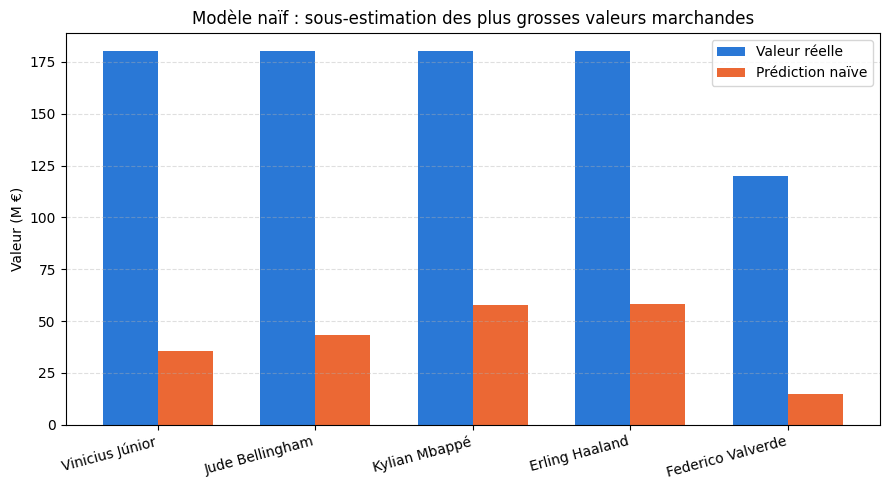

In [19]:
# On reprend le top 5 des plus grosses erreurs déjà calculé
top5 = df_comparaison.sort_values(by="Erreur (Ecart)", ascending=False).head(5)

x = np.arange(len(top5))
largeur = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - largeur/2, top5["Valeur Réelle"] / 1e6, largeur, label="Valeur réelle", color="#2a78d6")
ax.bar(x + largeur/2, top5["Prédiction Naïve"] / 1e6, largeur, label="Prédiction naïve", color="#eb6834")

ax.set_ylabel("Valeur (M €)")
ax.set_title("Modèle naïf : sous-estimation des plus grosses valeurs marchandes")
ax.set_xticks(x)
ax.set_xticklabels(top5["Joueur"], rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("graphe_top5_erreurs.png", dpi=150)
plt.show()

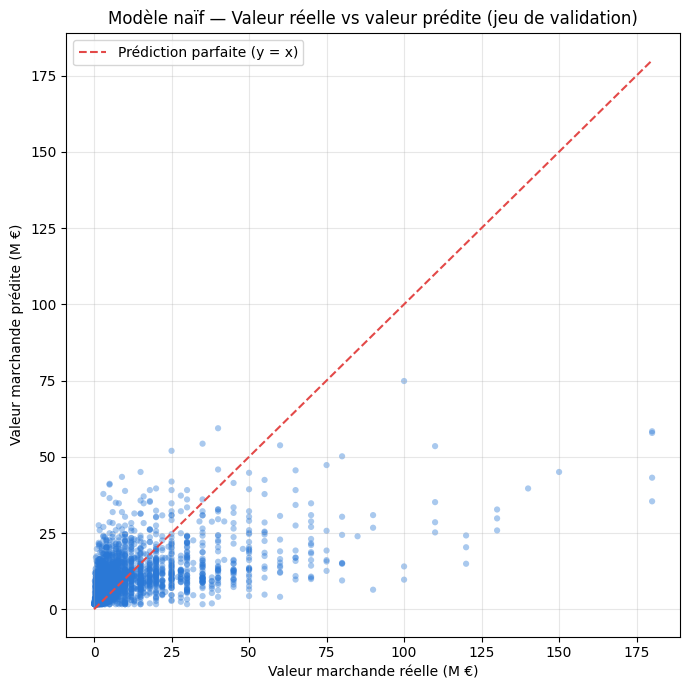

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))

# Nuage de points : chaque joueur du jeu de validation
ax.scatter(y_val / 1e6, y_pred_val / 1e6, alpha=0.4, s=20, color="#2a78d6", edgecolor="none")

# Ligne de référence y = x (prédiction parfaite)
max_val = max(y_val.max(), y_pred_val.max()) / 1e6
ax.plot([0, max_val], [0, max_val], color="#e34948", linestyle="--", linewidth=1.5, label="Prédiction parfaite (y = x)")

ax.set_xlabel("Valeur marchande réelle (M €)")
ax.set_ylabel("Valeur marchande prédite (M €)")
ax.set_title("Modèle naïf — Valeur réelle vs valeur prédite (jeu de validation)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphe_reel_vs_predit_validation.png", dpi=150)
plt.show()